Data shape: (7980, 49)
Countries: ['CAF' 'MDG' 'MOZ' 'SOM' 'SSD']
Date range: 2017-01-01 00:00:00 to 2025-09-01 00:00:00
Saved: 2. overall_distribution.png


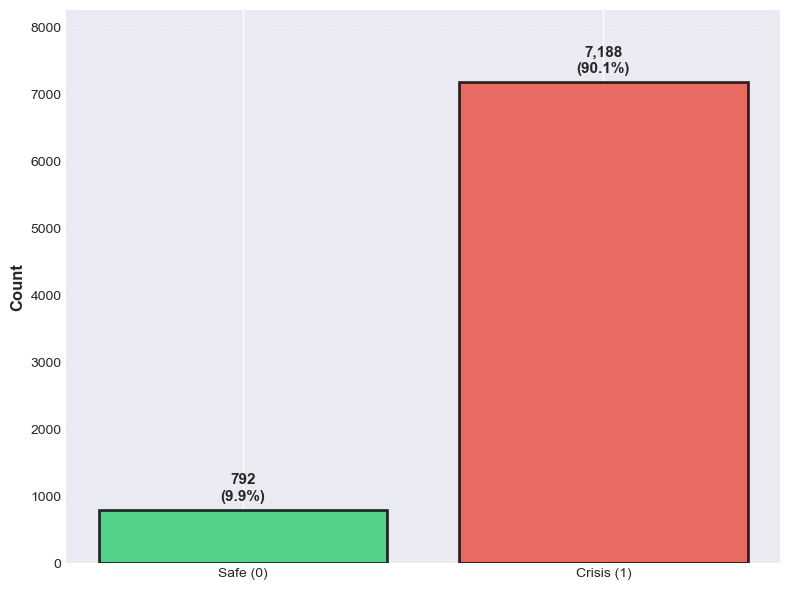

Saved:3. crisis_rate_by_country.png


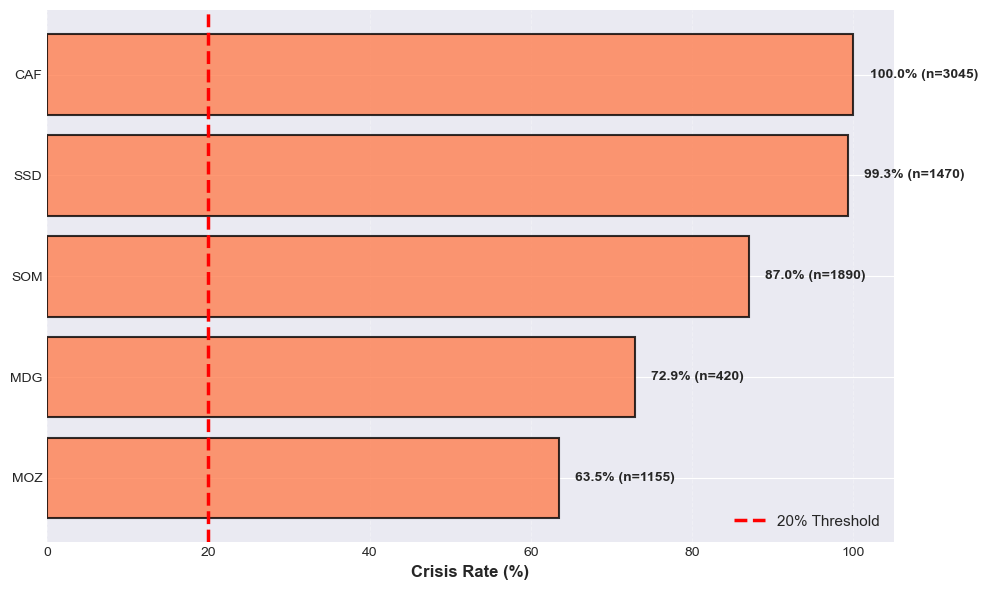

Saved: 4. monthly_crisis-rate_trend (2017–2025).png


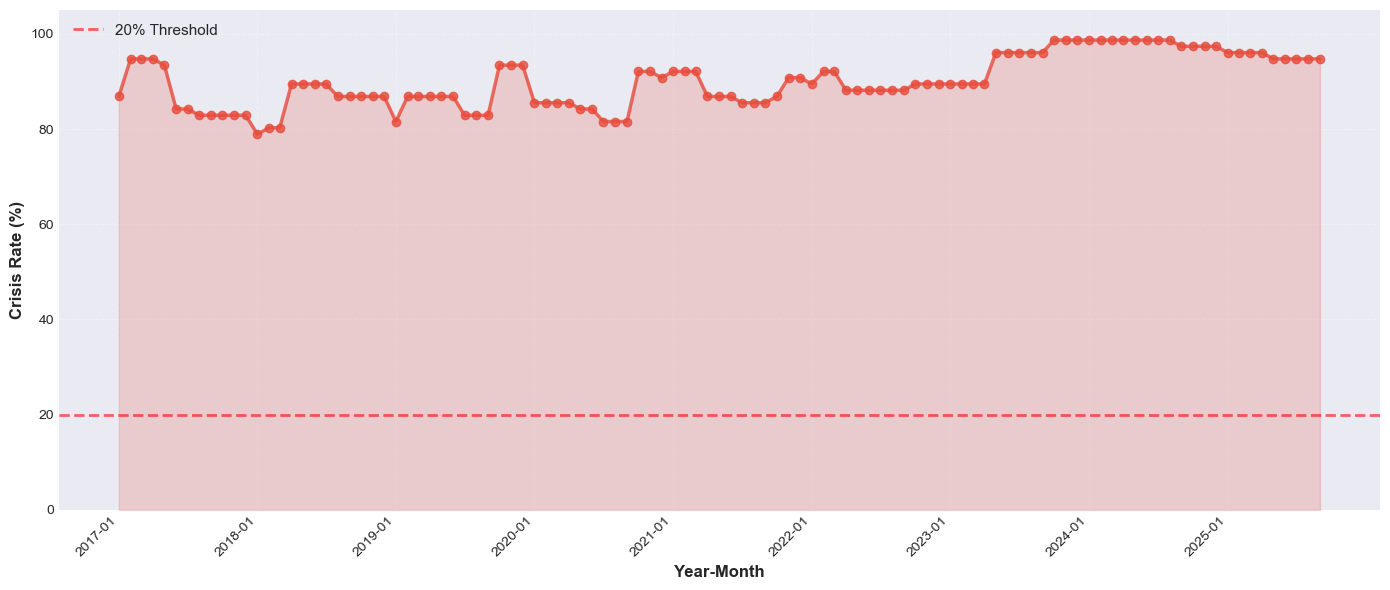

Saved: 5. seasonal_pattern_by_country.png


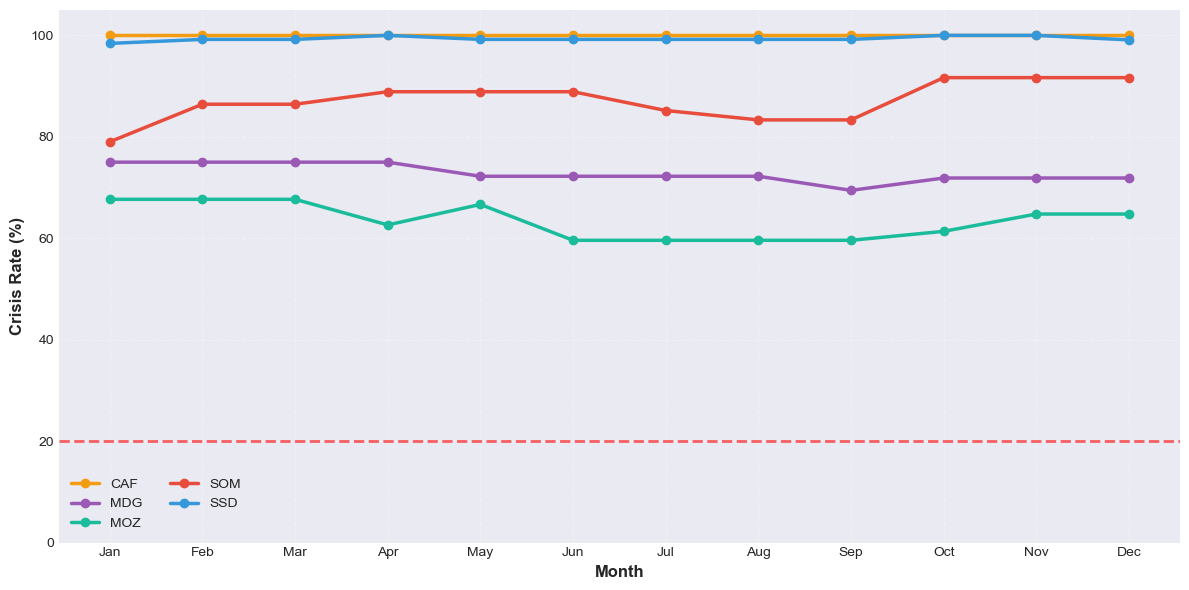

Saved: 6. year-over-year_crisis_rate.png


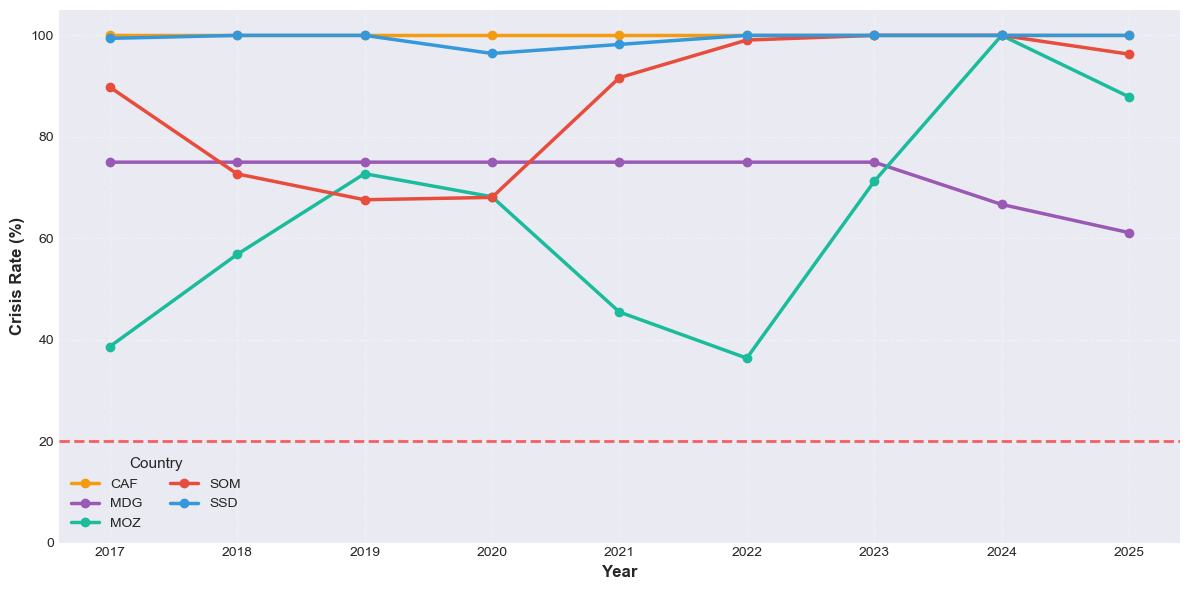


2. FEATURE-TARGET RELATIONSHIP
Saved:7. feature_vs_target.png

3. LAG FEATURE CORRELATION ANALYSIS (h1 + h3)
Saved: h1_lag_feature_importance.png


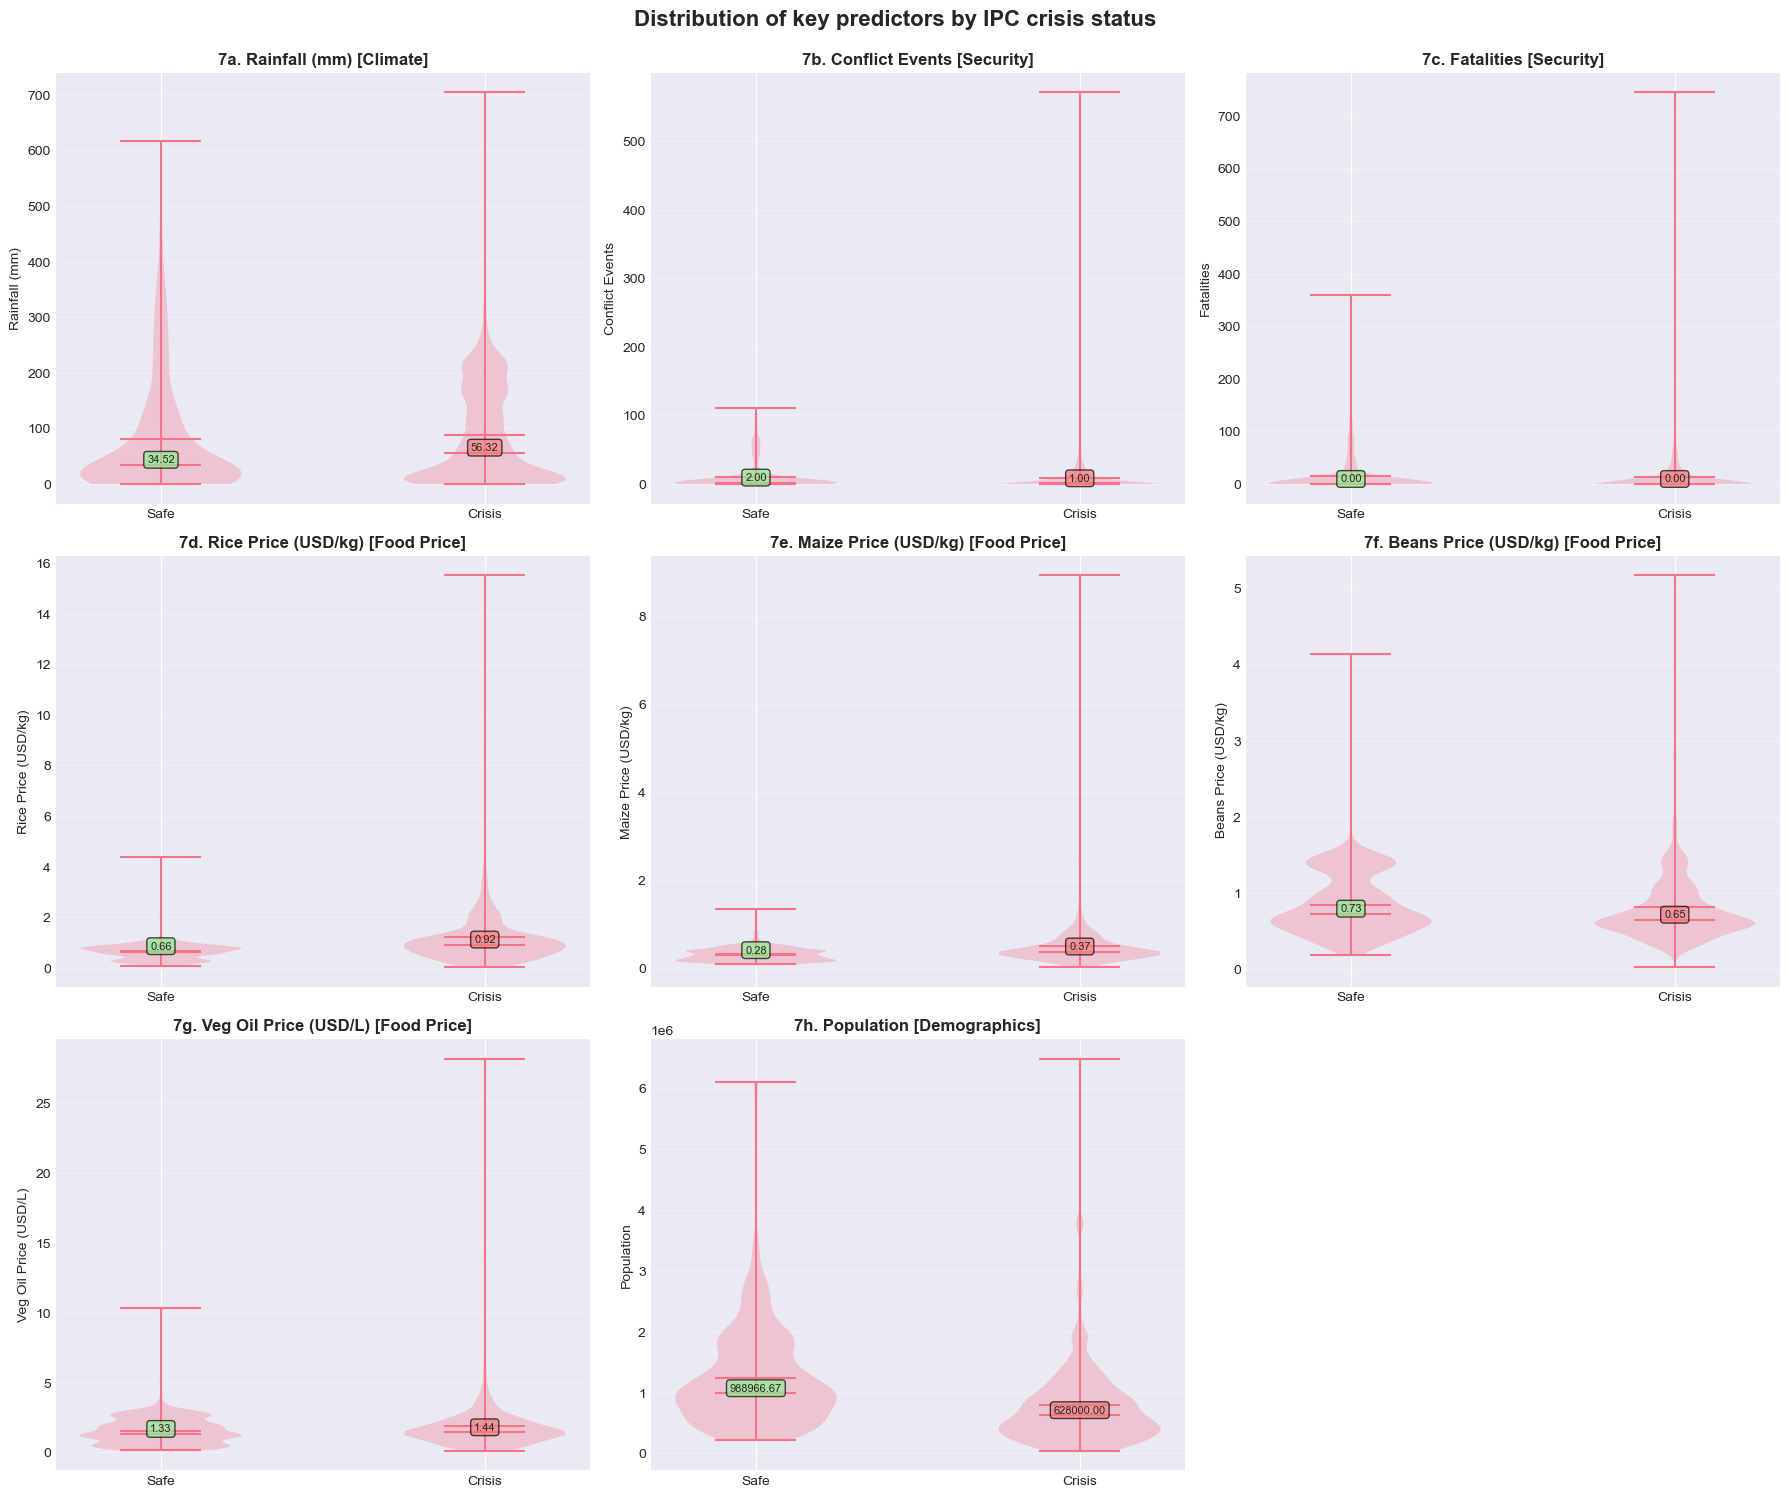

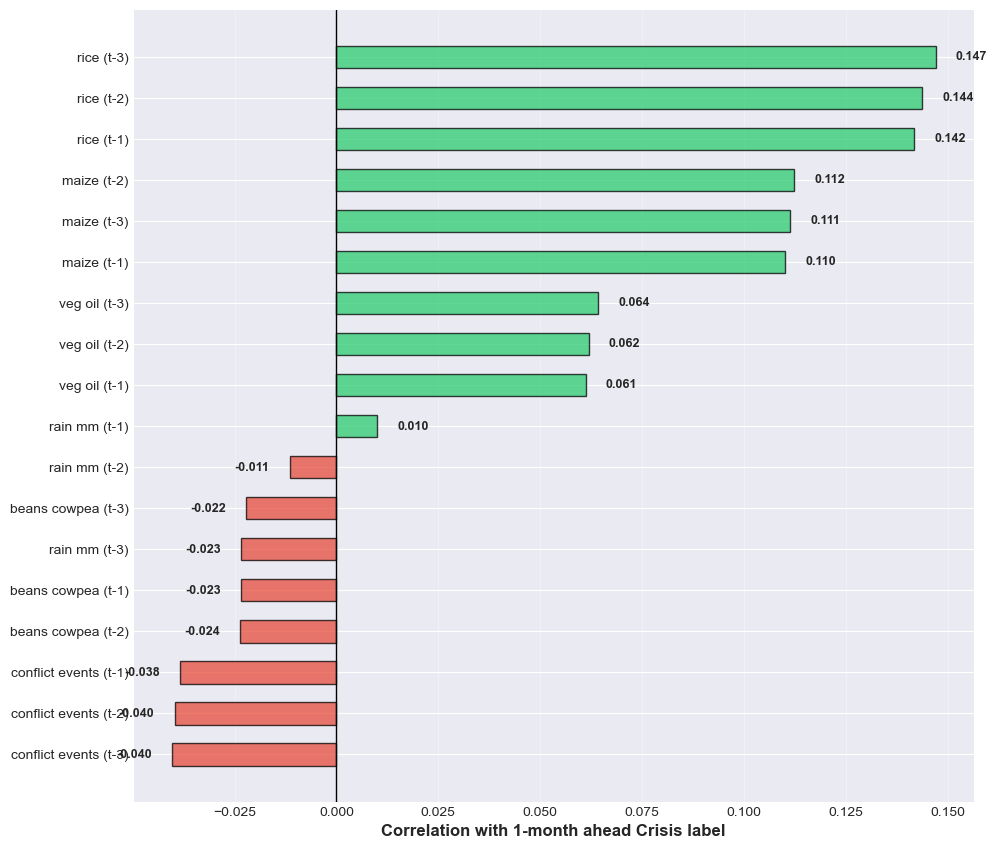

Saved: h3_lag_feature_importance.png


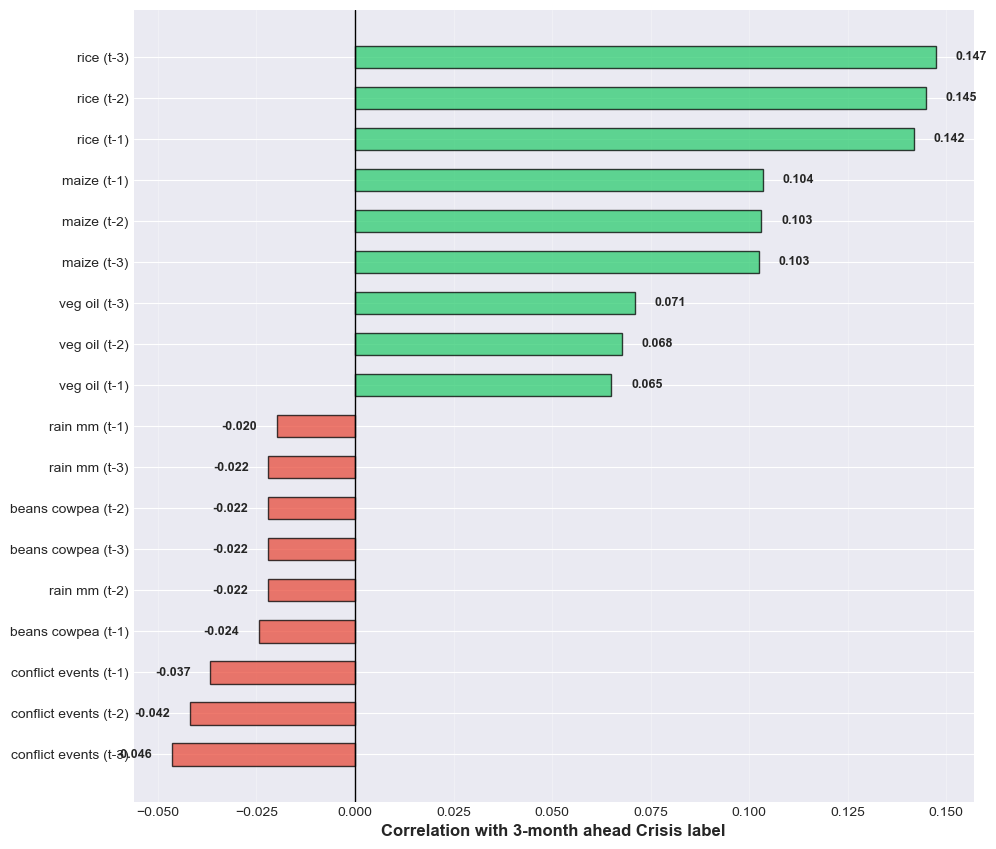


4. FEATURE CORRELATION MATRIX
   (These features are used to define the target label)

Saved: 9.correlation_matrix.png

5. DATA QUALITY SUMMARY

Top 10 Features with Missing Values:
             Feature  Missing_Rate_%   Dtype  Unique_Values
     fatalities_lag3        2.857143 float64            227
 admin1_pop_est_lag3        2.857143 float64           1220
conflict_events_lag3        2.857143 float64            110
        veg_oil_lag3        2.857143 float64           2472
        rain_mm_lag3        2.857143 float64           5567
           rice_lag3        2.857143 float64           2570
affected_num_3p_lag3        2.857143 float64           1106
          maize_lag3        2.857143 float64           2805
affected_pct_3p_lag3        2.857143 float64            217
   beans_cowpea_lag3        2.857143 float64           1811
Saved:16. features_with_missing_value.png

SUMMARY STATISTICS
Total Samples........................... 7980
Countries............................... 5
Admin1

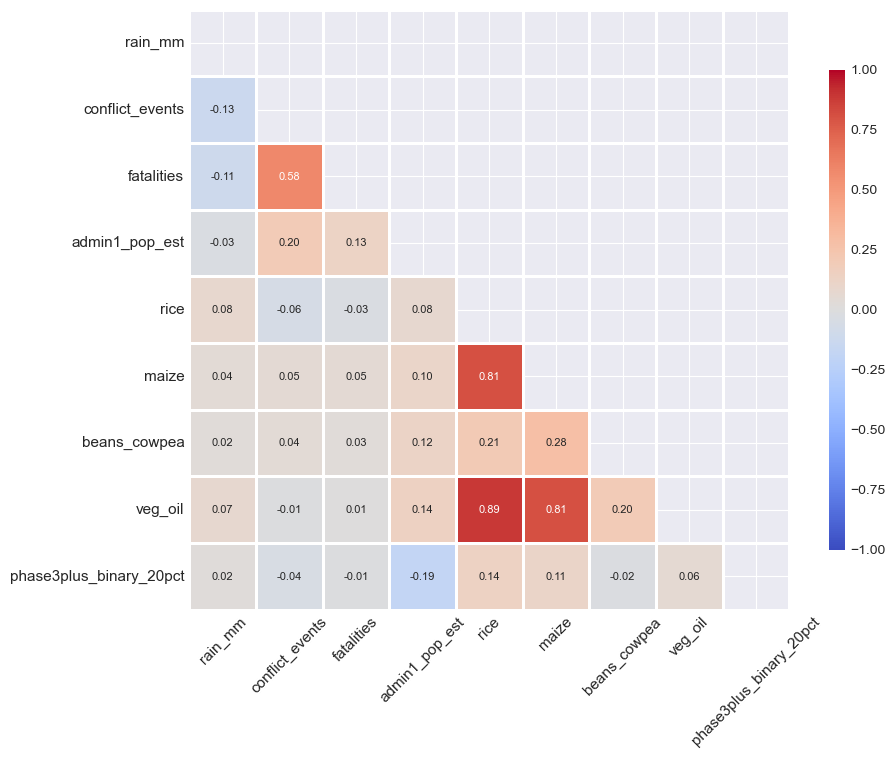

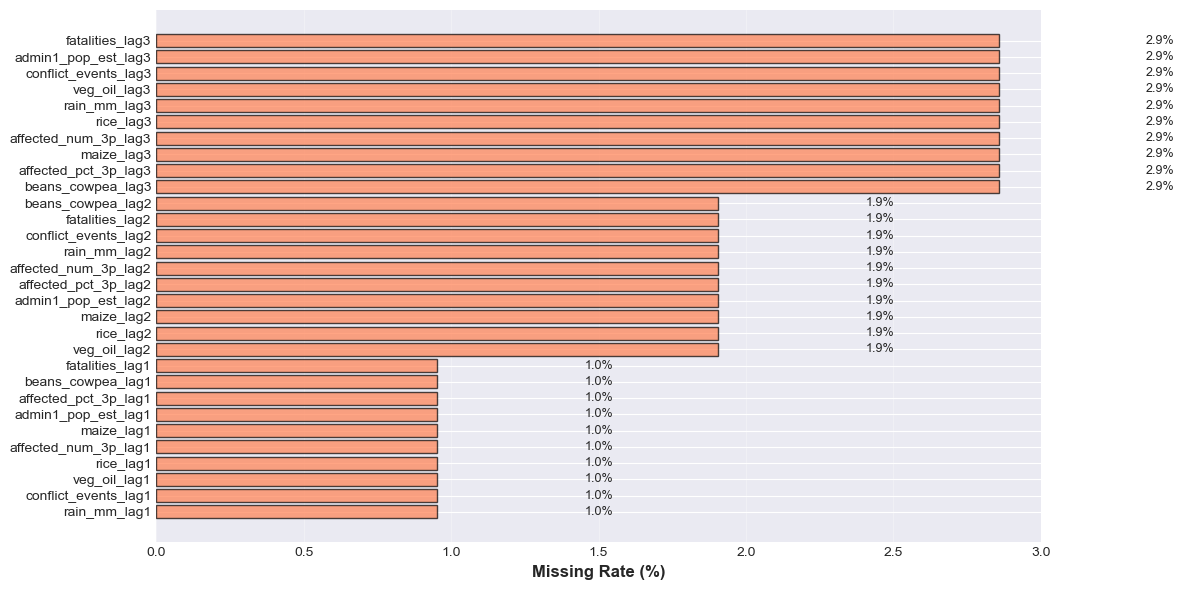

In [1]:
# ======================================================
# Priority EDA for Hunger Crisis Prediction
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

# ========== Configuration ==========
DATA_PATH = Path("data clean/train_features_2017_2025_lagged.csv")
OUTPUT_DIR = Path("eda_output")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ========== Load Data ==========
df = pd.read_csv(DATA_PATH)
df['year_month'] = pd.to_datetime(df['year_month'])
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

print(f"Data shape: {df.shape}")
print(f"Countries: {df['country'].unique()}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")

# ======================================================
# 1. TARGET VARIABLE ANALYSIS
# ======================================================

# ---------- 1.1 Overall Label Distribution ----------
fig, ax = plt.subplots(figsize=(8, 6))

# Ensure Safe (0) always comes before Crisis (1)
label_order = [0, 1]
colors = ['#2ecc71', '#e74c3c']  # green = Safe, red = Crisis
labels = ['Safe (0)', 'Crisis (1)']

counts = df['phase3plus_binary_20pct'].value_counts()
values = [counts.get(i, 0) for i in label_order]
percentages = [v / len(df) * 100 for v in values]

bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.02, f'{v:,}\n({percentages[i]:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2. overall_distribution.png', dpi=300, bbox_inches='tight')
print("Saved: 2. overall_distribution.png")
plt.show()
plt.close(fig)

# ---------- 1.2 Crisis Rate by Country ----------
fig, ax = plt.subplots(figsize=(10, 6))
country_label = df.groupby('country')['phase3plus_binary_20pct'].agg(['mean', 'count']).sort_values('mean')
ax.barh(country_label.index, country_label['mean'] * 100,
        color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axvline(20, color='red', linestyle='--', linewidth=2.5, label='20% Threshold')
ax.set_xlabel('Crisis Rate (%)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3, linestyle='--')
for i, (idx, row) in enumerate(country_label.iterrows()):
    ax.text(row['mean'] * 100 + 2, i, f"{row['mean'] * 100:.1f}% (n={int(row['count'])})",
            va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '3. crisis_rate_by_country.png', dpi=300, bbox_inches='tight')
print("Saved:3. crisis_rate_by_country.png")
plt.show()
plt.close(fig)

# ---------- 1.3 Monthly Crisis Rate Trend ----------
fig, ax = plt.subplots(figsize=(14, 6))
monthly_crisis = df.groupby('year_month')['phase3plus_binary_20pct'].mean() * 100
ax.plot(monthly_crisis.index, monthly_crisis.values,
        marker='o', linewidth=2.5, color='#e74c3c', alpha=0.8)
ax.axhline(20, color='red', linestyle='--', linewidth=2, alpha=0.6, label='20% Threshold')
ax.fill_between(monthly_crisis.index, 0, monthly_crisis.values, alpha=0.2, color='#e74c3c')
ax.set_xlabel('Year-Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Crisis Rate (%)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 105)
date_ticks = monthly_crisis.index[::12]
ax.set_xticks(date_ticks)
ax.set_xticklabels([d.strftime('%Y-%m') for d in date_ticks], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '4. monthly_crisis-rate_trend (2017–2025).png', dpi=300, bbox_inches='tight')
print("Saved: 4. monthly_crisis-rate_trend (2017–2025).png")
plt.show()
plt.close(fig)

# ---------- 1.4 Seasonal Pattern by Country ----------
fig, ax = plt.subplots(figsize=(12, 6))
seasonal = df.groupby(['country', 'month'])['phase3plus_binary_20pct'].mean().unstack() * 100
color_map = {'SOM': '#e74c3c', 'SSD': '#3498db', 'CAF': '#f39c12', 'MDG': '#9b59b6', 'MOZ': '#1abc9c'}

for country in seasonal.index:
    ax.plot(seasonal.columns, seasonal.loc[country],
            marker='o', linewidth=2.5, label=country, color=color_map.get(country, 'gray'))

ax.axhline(20, color='red', linestyle='--', linewidth=2, alpha=0.6)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Crisis Rate (%)', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(fontsize=10, loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '5. seasonal_pattern_by_country.png', dpi=300, bbox_inches='tight')
print("Saved: 5. seasonal_pattern_by_country.png")
plt.show()
plt.close(fig)

# ---------- 1.5 Year-over-Year Crisis Rate ----------
fig, ax = plt.subplots(figsize=(12, 6))
yearly = df.groupby(['country', 'year'])['phase3plus_binary_20pct'].mean().unstack() * 100
for country in yearly.index:
    ax.plot(yearly.columns, yearly.loc[country],
            marker='o', linewidth=2.5, label=country, color=color_map.get(country, 'gray'))
ax.axhline(20, color='red', linestyle='--', linewidth=2, alpha=0.6)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Crisis Rate (%)', fontsize=12, fontweight='bold')
ax.legend(title='Country', fontsize=10, title_fontsize=11, loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 105)
ax.set_xticks(yearly.columns)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '6. year-over-year_crisis_rate.png', dpi=300, bbox_inches='tight')
print("Saved: 6. year-over-year_crisis_rate.png")
plt.show()
plt.close(fig)

# ======================================================
# 2. FEATURE vs TARGET RELATIONSHIPS
# ======================================================

print("\n" + "="*50)
print("2. FEATURE-TARGET RELATIONSHIP")
print("="*50)

# Define feature groups (exclude potential leakage variables)
feature_specs = [
    ('rain_mm', ('7a. Rainfall (mm)','Rainfall (mm)'), 'Climate'),
    ('conflict_events', ('7b. Conflict Events','Conflict Events'), 'Security'),
    ('fatalities', ('7c. Fatalities','Fatalities'), 'Security'),
    ('rice', ('7d. Rice Price (USD/kg)', 'Rice Price (USD/kg)'), 'Food Price'),
    ('maize', ('7e. Maize Price (USD/kg)','Maize Price (USD/kg)'), 'Food Price'),
    ('beans_cowpea', ('7f. Beans Price (USD/kg)',' Beans Price (USD/kg)'), 'Food Price'),
    ('veg_oil', ('7g. Veg Oil Price (USD/L)','Veg Oil Price (USD/L)'), 'Food Price'),
    ('admin1_pop_est', ('7h. Population','Population'), 'Demographics')
]

available_features = [(col, label, cat) for col, label, cat in feature_specs if col in df.columns]

n_features = len(available_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]
fig.suptitle('Distribution of key predictors by IPC crisis status',
             fontsize=16, fontweight='bold', y=0.995)

for idx, (col, (label_title, label_y),  category) in enumerate(available_features):
    safe_data = df[df['phase3plus_binary_20pct'] == 0][col].dropna()
    crisis_data = df[df['phase3plus_binary_20pct'] == 1][col].dropna()
    safe_median = safe_data.median()
    crisis_median = crisis_data.median()

    axes[idx].violinplot([safe_data, crisis_data],
                         positions=[0, 1], showmeans=True, showmedians=True)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Safe', 'Crisis'])
    axes[idx].set_ylabel(label_y)
    axes[idx].set_title(f'{label_title} [{category}]', fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].text(0, safe_median, f'{safe_median:.2f}', ha='center', va='bottom',
                   fontsize=8, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    axes[idx].text(1, crisis_median, f'{crisis_median:.2f}', ha='center', va='bottom',
                   fontsize=8, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '7. feature_vs_target.png', dpi=300, bbox_inches='tight')
print("Saved:7. feature_vs_target.png")

# ======================================================
# 3. LAG FEATURE CORRELATION ANALYSIS
# ======================================================

print("\n" + "="*50)
print("3. LAG FEATURE CORRELATION ANALYSIS (h1 + h3)")
print("="*50)


lag_cols = [c for c in df.columns if '_lag' in c and c.startswith(
    ('rain', 'conflict', 'rice', 'maize', 'beans_cowpea', 'veg_oil'))
]

# Loop over two horizons (h1, h3)
for horizon, label_text, file_suffix in [
    ('phase3plus_binary_20pct_h1', '1-month ahead Crisis', 'h1'),
    ('phase3plus_binary_20pct_h3', '3-month ahead Crisis', 'h3')
]:
    if horizon not in df.columns:
        print(f"Skipping {horizon} — column not found")
        continue


    correlations = (
        df[lag_cols + [horizon]]
        .corr()[horizon]
        .drop(horizon)
        .sort_values()
    )


    fig, ax = plt.subplots(figsize=(12, max(8, len(correlations) * 0.55)))

    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
    ax.barh(range(len(correlations)), correlations.values,
            color=colors, alpha=0.75, edgecolor='black', height=0.55)

    ax.set_yticks(range(len(correlations)))
    ax.set_yticklabels(
        [c.replace('_lag', ' (t-').replace('_', ' ') + ')' for c in correlations.index],
        fontsize=10
    )
    ax.set_xlabel(f'Correlation with {label_text} label', fontsize=12, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')


    text_gap = 0.005
    for v, y in zip(correlations.values, np.arange(len(correlations))):
        ha = 'left' if v >= 0 else 'right'
        ax.text(v + (text_gap if v >= 0 else -text_gap), y,
                f'{v:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(left=0.25, right=0.95, top=0.9, bottom=0.1)


    outfile = OUTPUT_DIR / f'{file_suffix}_lag_feature_importance.png'
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    print(f"Saved: {outfile.name}")
    plt.show()


# ======================================================
# 4. CORRELATION MATRIX (MULTICOLLINEARITY CHECK)
# ======================================================

print("\n" + "="*50)
print("4. FEATURE CORRELATION MATRIX")
print("="*50)

main_features = ['rain_mm', 'conflict_events', 'fatalities', 'admin1_pop_est']
food_prices = ['rice', 'maize', 'beans_cowpea', 'veg_oil', 'wheat_flour']
for food in food_prices:
    if food in df.columns:
        main_features.append(food)

print("   (These features are used to define the target label)\n")

main_features.append('phase3plus_binary_20pct')

# Compute correlation matrix
corr_matrix = df[main_features].corr()

# Dynamically adjust figure size and font based on feature count
n_features = len(corr_matrix.columns)
fig_width = max(10, n_features * 0.8)
fig_height = max(8, n_features * 0.6)
annot_font = 8 if n_features > 8 else 10
tick_font = 9 if n_features > 10 else 11

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=1, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8, "aspect": 30}, ax=ax,
    annot_kws={"size": annot_font}
)

ax.tick_params(axis='x', labelrotation=45, labelsize=tick_font)
ax.tick_params(axis='y', labelrotation=0, labelsize=tick_font)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.90)
plt.savefig(OUTPUT_DIR / '9.correlation_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: 9.correlation_matrix.png")


# ======================================================
# 5. DATA QUALITY REPORT
# ======================================================

print("\n" + "="*50)
print("5. DATA QUALITY SUMMARY")
print("="*50)

quality_report = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Rate_%': (df.isnull().sum() / len(df) * 100).values,
    'Dtype': df.dtypes.values,
    'Unique_Values': [df[col].nunique() for col in df.columns]
}).sort_values('Missing_Rate_%', ascending=False)

print("\nTop 10 Features with Missing Values:")
print(quality_report[quality_report['Missing_Rate_%'] > 0].head(10).to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_features = quality_report[quality_report['Missing_Rate_%'] > 0].sort_values('Missing_Rate_%', ascending=True)
if not missing_features.empty:
    ax.barh(missing_features['Feature'], missing_features['Missing_Rate_%'],
            color='coral', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Missing Rate (%)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(missing_features['Missing_Rate_%'].values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '16. features_with_missing_values.png', dpi=300, bbox_inches='tight')
    print("Saved:16. features_with_missing_value.png")

# ======================================================
# SUMMARY STATISTICS
# ======================================================

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

summary = {
    'Total Samples': len(df),
    'Countries': df['country'].nunique(),
    'Admin1 Regions': df['admin1'].nunique(),
    'Time Span (months)': df['year_month'].nunique(),
    'Overall Crisis Rate (%)': f"{df['phase3plus_binary_20pct'].mean()*100:.2f}",
    'Class Imbalance Ratio': f"1:{(1-df['phase3plus_binary_20pct'].mean())/df['phase3plus_binary_20pct'].mean():.2f}",
}

for key, value in summary.items():
    print(f"{key:.<40} {value}")

print(f"\n{'='*50}")
print(f"All EDA outputs saved to: {OUTPUT_DIR}")
print(f"{'='*50}")

plt.show()
